# Notebook 3: Model Training and Explainability

Train an XGBoost classifier to predict loan default, evaluate it, and produce SHAP explanations.

Steps:
1. Load processed data
2. Train/test split
3. Handle class imbalance
4. Train XGBoost
5. Evaluate (ROC-AUC, precision-recall, confusion matrix)
6. SHAP explainability
7. Persist the model, explainer, and stats for the Streamlit app

In [1]:
import json
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load processed data

In [2]:
X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_processed.csv').squeeze()

with open('../models/feature_names.json') as f:
    FEATURES = json.load(f)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Default rate: {y.mean():.2%}')

X shape: (897167, 19)
y shape: (897167,)
Default rate: 17.56%


## 2. Train/test split

Stratified by the target so both splits keep the same default rate.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows | Default rate: {y_train.mean():.2%}')
print(f'Test set:     {X_test.shape[0]:,} rows | Default rate: {y_test.mean():.2%}')

Training set: 717,733 rows | Default rate: 17.56%
Test set:     179,434 rows | Default rate: 17.56%


## 3. Class imbalance

Defaults are the minority class. Rather than resampling, we set `scale_pos_weight = neg_count / pos_count` so XGBoost penalises missed defaults proportionally.

In [4]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Non-default (0): {neg_count:,}')
print(f'Default (1):     {pos_count:,}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Non-default (0): 591,687
Default (1):     126,046
scale_pos_weight: 4.69


## 4. Train XGBoost

In [5]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

[0]	validation_0-auc:0.94140


[50]	validation_0-auc:0.96643


[100]	validation_0-auc:0.97186


[150]	validation_0-auc:0.97372


[200]	validation_0-auc:0.97494


[250]	validation_0-auc:0.97574


[299]	validation_0-auc:0.97628


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## 5. Evaluation

For credit risk, recall on the positive class (catching actual defaults) matters more than overall accuracy.

In [6]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print('Model performance')
print('-----------------')
print(f'ROC-AUC:           {roc_auc:.4f}')
print(f'Average precision: {avg_precision:.4f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Paid in Full', 'Default']))

Model performance
-----------------
ROC-AUC:           0.9763
Average precision: 0.9035

Classification report:
              precision    recall  f1-score   support

Paid in Full       0.98      0.92      0.95    147922
     Default       0.72      0.93      0.81     31512

    accuracy                           0.92    179434
   macro avg       0.85      0.93      0.88    179434
weighted avg       0.94      0.92      0.93    179434



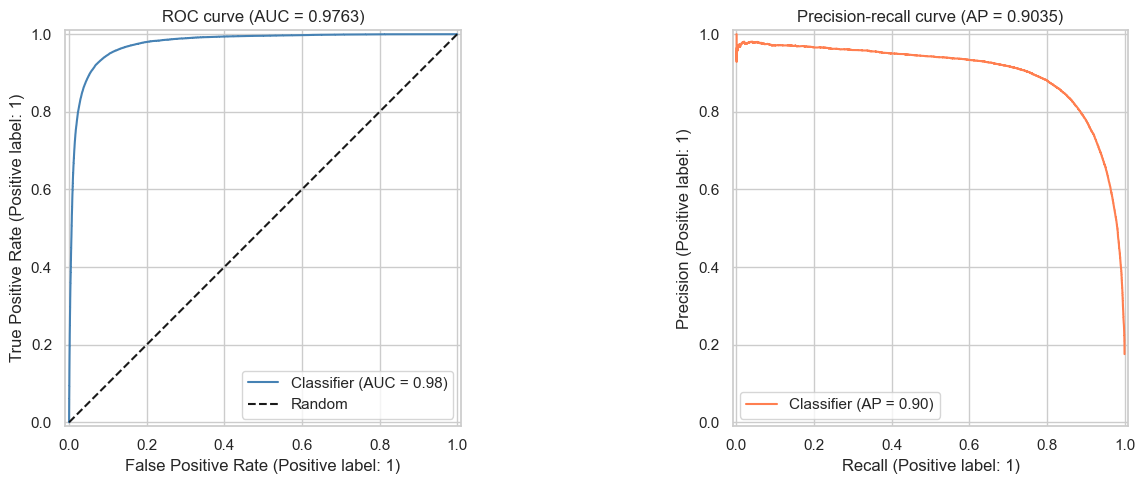

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title(f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color='coral')
axes[1].set_title(f'Precision-recall curve (AP = {avg_precision:.4f})')

plt.tight_layout()
plt.show()

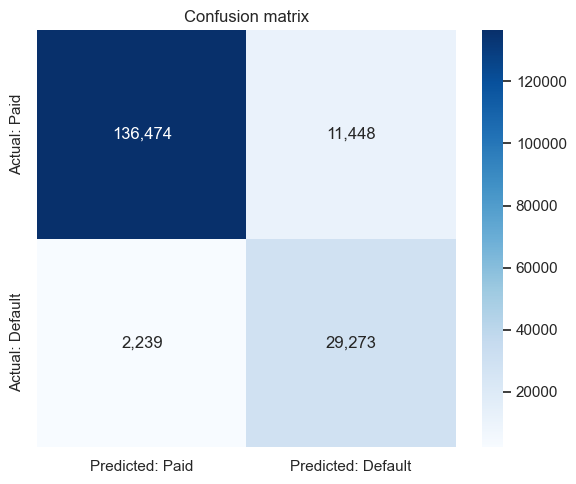

True negatives  (correctly predicted Paid):    136,474
False positives (predicted Default, actually Paid): 11,448
False negatives (predicted Paid, actually Default): 2,239
True positives  (correctly predicted Default): 29,273


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted: Paid', 'Predicted: Default'],
            yticklabels=['Actual: Paid', 'Actual: Default'])
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True negatives  (correctly predicted Paid):    {tn:,}')
print(f'False positives (predicted Default, actually Paid): {fp:,}')
print(f'False negatives (predicted Paid, actually Default): {fn:,}')
print(f'True positives  (correctly predicted Default): {tp:,}')

## 6. Feature importance

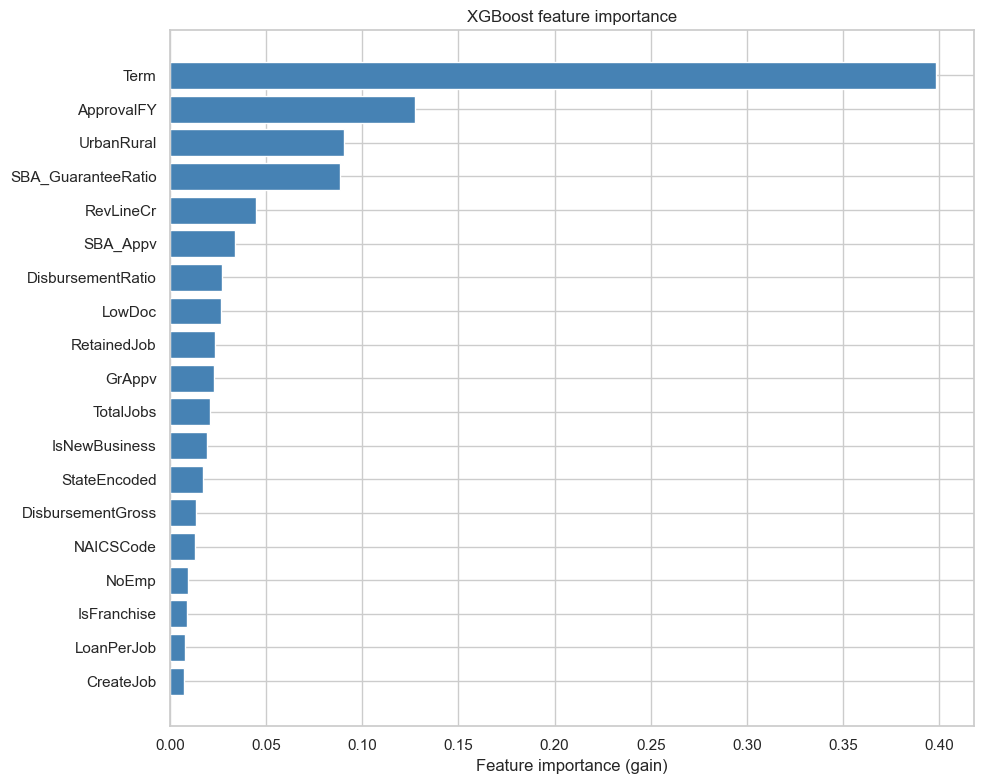

In [9]:
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.xlabel('Feature importance (gain)')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.show()

## 7. SHAP explainability

SHAP values decompose each prediction into per-feature contributions. The fitted explainer is also persisted so the Streamlit app can compute explanations on demand.

In [10]:
# Sample for speed; SHAP over the full test set is expensive.
X_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

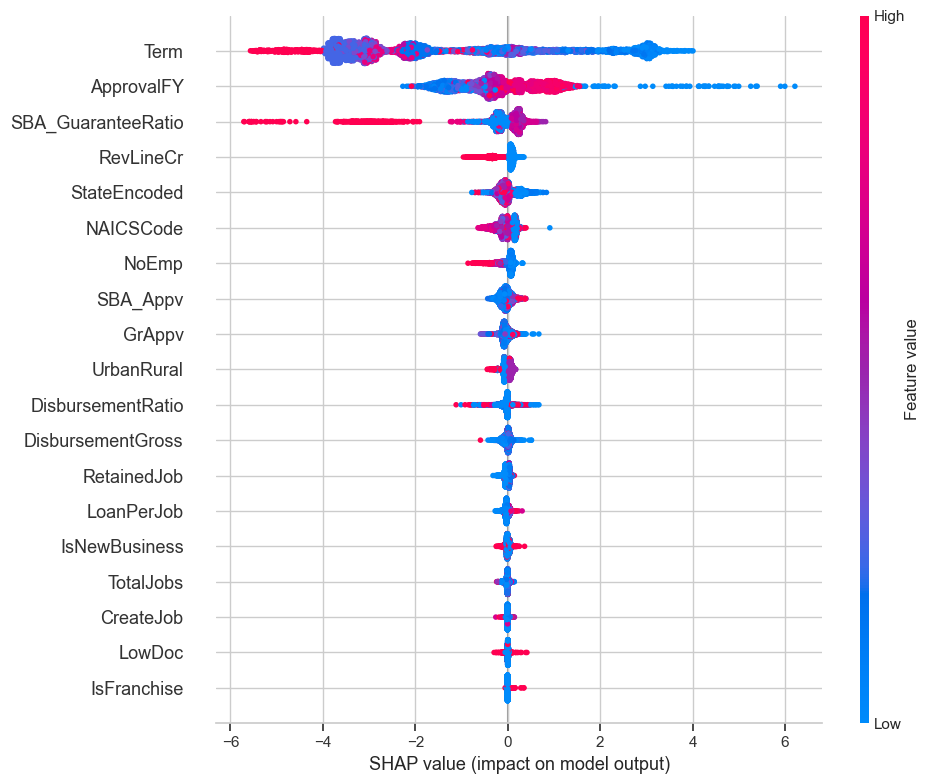

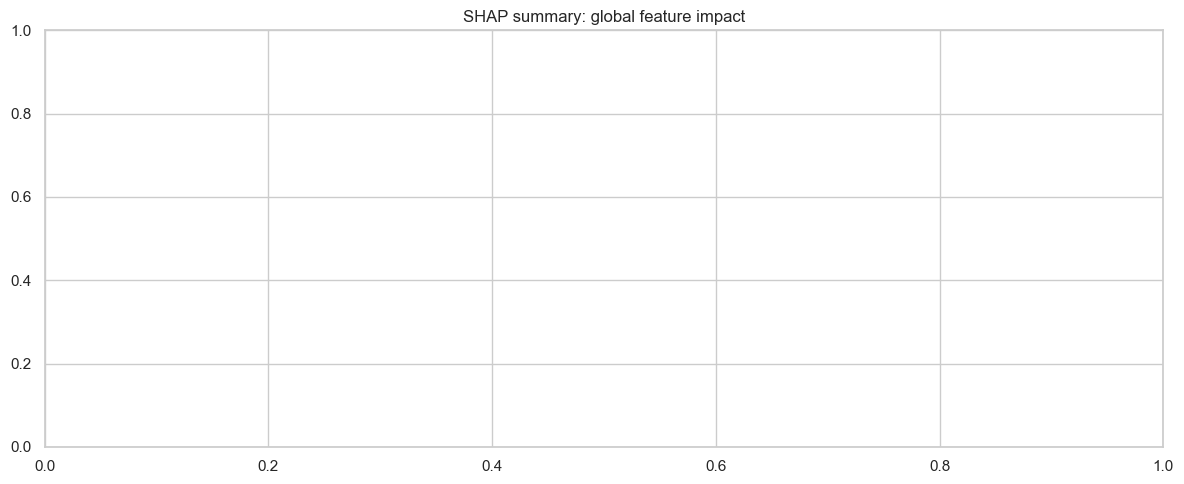

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, plot_size=(10, 8))
plt.title('SHAP summary: global feature impact')
plt.tight_layout()
plt.show()

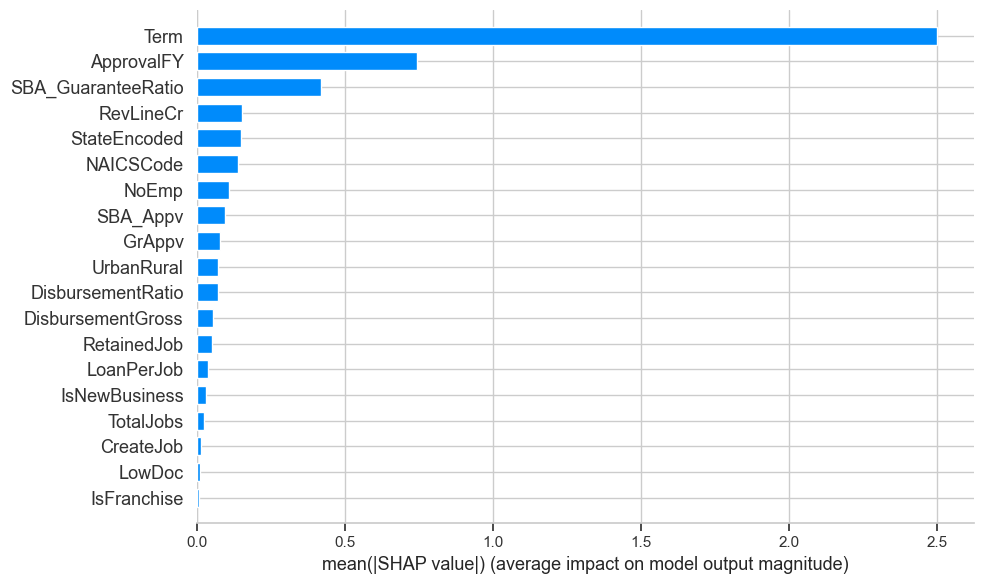

In [12]:
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, plot_type='bar', plot_size=(10, 6))

Risk score: 99.79%
Actual outcome: DEFAULT


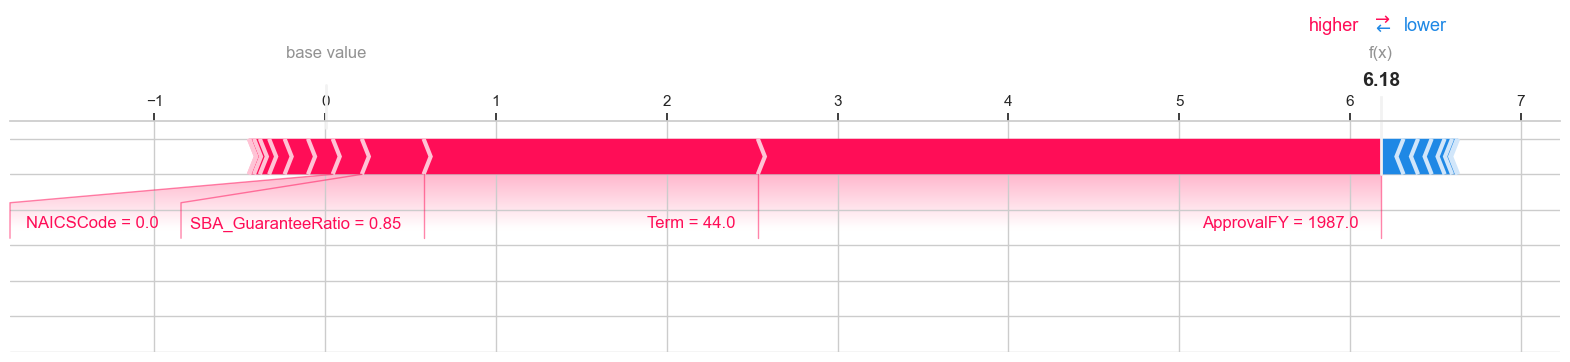

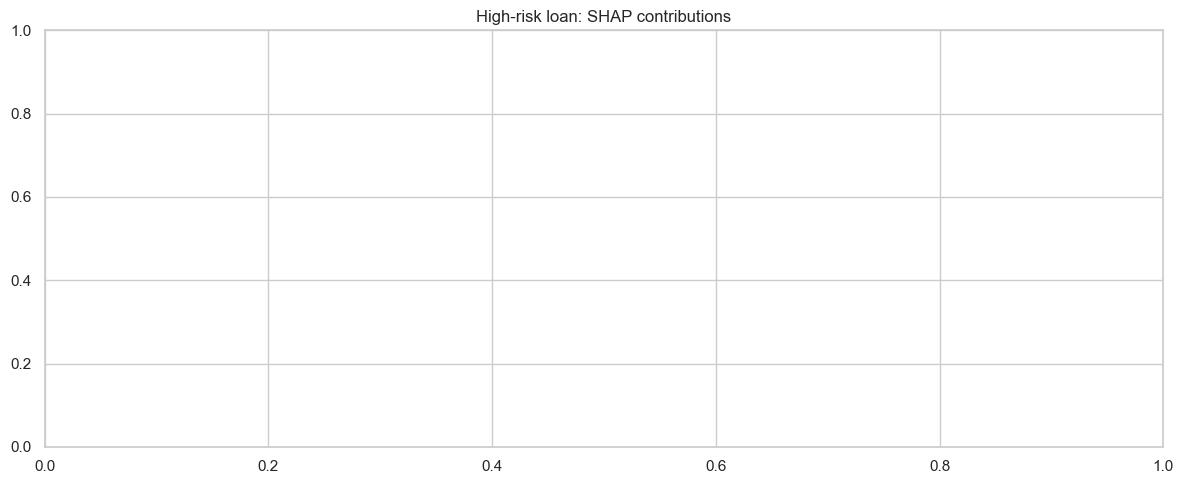

In [13]:
# Explain the highest-confidence default in the sample.
proba_sample = model.predict_proba(X_sample)[:, 1]
high_risk_idx = proba_sample.argmax()
high_risk_loan = X_sample.iloc[[high_risk_idx]]

print(f'Risk score: {proba_sample[high_risk_idx]:.2%}')
print(f'Actual outcome: {"DEFAULT" if y_test.iloc[high_risk_idx] == 1 else "PAID"}')

shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    high_risk_loan,
    feature_names=FEATURES,
    matplotlib=True,
)
plt.title('High-risk loan: SHAP contributions')
plt.tight_layout()
plt.show()

Risk score: 0.02%
Actual outcome: PAID


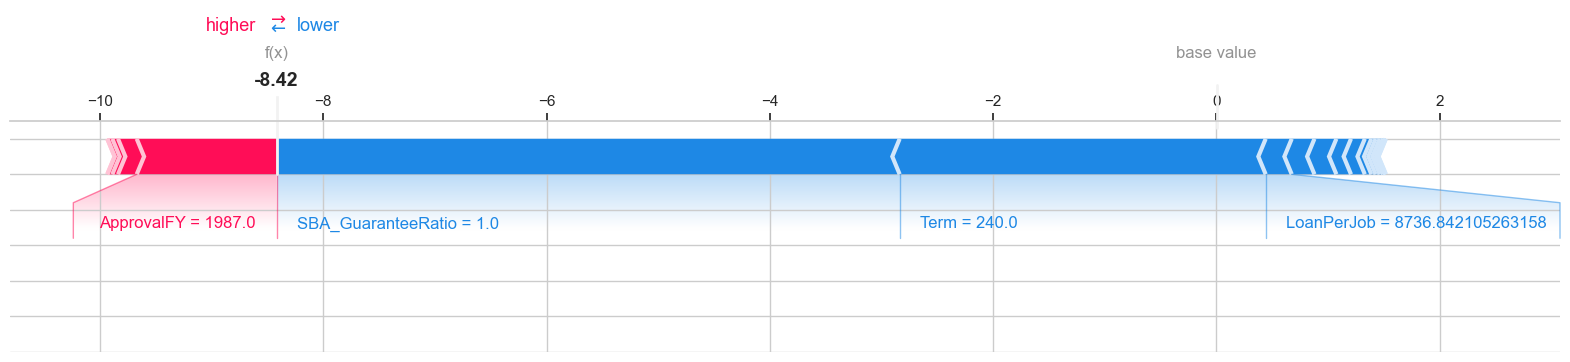

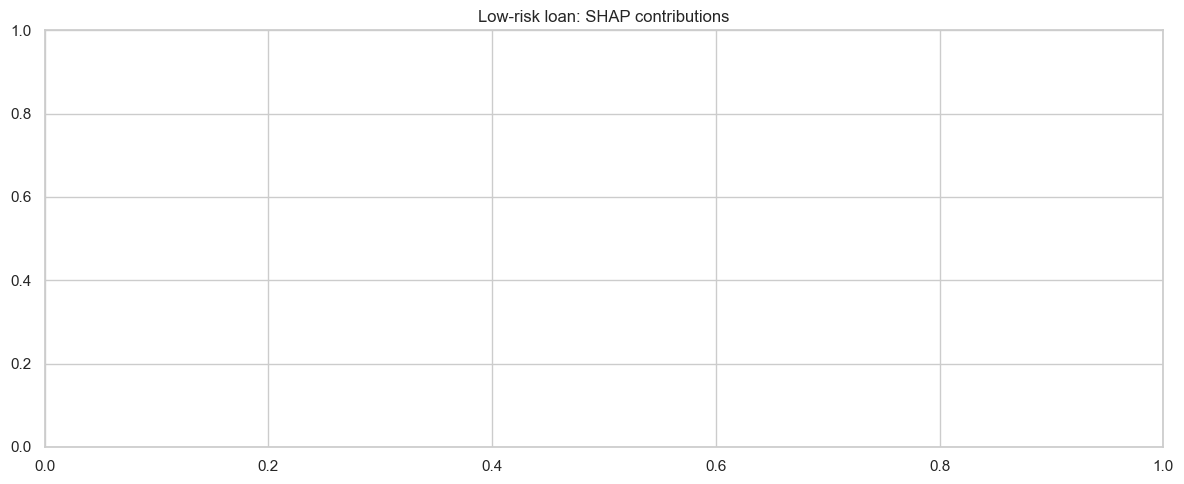

In [14]:
# Explain the lowest-confidence default (i.e. the most clearly safe loan).
low_risk_idx = proba_sample.argmin()
low_risk_loan = X_sample.iloc[[low_risk_idx]]

print(f'Risk score: {proba_sample[low_risk_idx]:.2%}')
print(f'Actual outcome: {"DEFAULT" if y_test.iloc[low_risk_idx] == 1 else "PAID"}')

shap.force_plot(
    explainer.expected_value,
    shap_values[low_risk_idx],
    low_risk_loan,
    feature_names=FEATURES,
    matplotlib=True,
)
plt.title('Low-risk loan: SHAP contributions')
plt.tight_layout()
plt.show()

## 8. Persist artifacts

In [15]:
joblib.dump(model, '../models/xgb_loan_default.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')

stats = {
    'roc_auc': round(roc_auc, 4),
    'avg_precision': round(avg_precision, 4),
    'default_rate': round(float(y.mean()), 4),
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
}

with open('../models/model_stats.json', 'w') as f:
    json.dump(stats, f)

print('Wrote:')
print('  ../models/xgb_loan_default.pkl')
print('  ../models/shap_explainer.pkl')
print('  ../models/model_stats.json')

Wrote:
  ../models/xgb_loan_default.pkl
  ../models/shap_explainer.pkl
  ../models/model_stats.json
